# Observation scoring for filter predictive distributions

Filters approximate the one-step-ahead predictive observation distribution
\(p(y_t \mid y_{1:t-1}, 	heta)\). Once those predictions are available,
we can ask more than "what is the marginal likelihood?" We can also score
how well the predicted observation distributions match the realized data.

In `dynestyx` this is driven by `ObservationScoringConfig`:

- `Filter(..., scoring_config=...)` computes score arrays at each observation time.
- the filter can also record predicted observation means, covariances, and ensembles as NumPyro sites.
- those per-time score arrays can then be aggregated later for hyperparameter tuning, profile diagnostics, or MCMC health checks.

Here we use a partially observed, noisy Lorenz-63 system, simulate with burn-in so the retained data live on the attractor, and compare several continuous-time filters. We will:

1. record the predicted observation sites and the score sites,
2. compare EnKF runs with different ensemble sizes `N_particles` against EKF/UKF baselines at the true parameter,
3. build score profiles over an unknown `rho` for the same filter family.


## Setup

We score the **data-predictive** distribution by default. For EnKF, `sample_source="auto"`
means that energy scores will use a backend-provided observation ensemble when available,
and otherwise `dynestyx` will add observation noise `R` to the latent predictive observation
ensemble automatically.


In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from matplotlib.lines import Line2D
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    ScalarDiffusion,
    SDESimulator,
)
from dynestyx.inference.filter_configs import (
    ContinuousTimeEKFConfig,
    ContinuousTimeEnKFConfig,
    ContinuousTimeUKFConfig,
)
from dynestyx.inference.scoring import (
    DawidSebastianiScore,
    EnergyScore,
    GaussianLogProbScore,
    ObservationScoringConfig,
    ObservationWiseCRPSScore,
)

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings(
    "ignore",
    message="A JAX array is being set as static!",
)



## Lorenz-63 with partial noisy observations

We observe only the first state component with Gaussian noise,
so the latent state is 3-dimensional while the observation is scalar.
That keeps the model partially observed while making the score plots easy to read.

To avoid scoring the initial transient, we simulate a longer trajectory,
discard a burn-in segment, and keep only the last 15 time units for filtering.
We also use a smaller diffusion coefficient than before so the attractor structure is easier to see.


In [2]:
STATE_DIM = 3
OBS_DIM = 1
TRUE_RHO = 28.0
OBS_DT = 0.05
OBS_BURN_IN_TIME = 100.0
OBS_FINAL_TIME = 15.0
DIFFUSION_SCALE = 0.1
GAUSSIAN_SCORE_SAMPLES = 128
FILTER_DT0 = 0.005
PARTICLE_AXIS_METHOD = "scan"
OBS_TIMES = jnp.arange(0.0, OBS_FINAL_TIME + 1e-9, OBS_DT)
FULL_SIM_TIMES = jnp.arange(0.0, OBS_BURN_IN_TIME + OBS_FINAL_TIME + 1e-9, OBS_DT)
N_PARTICLES_VALUES = [10, 20, 30, 40, 50, 100, 150, 200, 250, 300]
PROFILE_N_PARTICLES_VALUES = [10, 30, 100]
CRN_SEED_INTS = list(range(10))
RHO_GRID = jnp.linspace(22.0, 34.0, 13)

METRIC_SPECS = [
    ("f_gaussian_log_prob", "Gaussian log-prob", "higher"),
    ("f_dawid_sebastiani", "Dawid-Sebastiani", "lower"),
    ("f_observation_wise_crps", "Observation-wise CRPS", "lower"),
    ("f_energy_score", "Energy score (beta=1.0)", "lower"),
    ("f_energy_score_beta_1_5", "Energy score (beta=1.5)", "lower"),
]
METRIC_SITE_NAMES = tuple(site_name for site_name, _, _ in METRIC_SPECS)
ALL_PARTICLE_VALUES = tuple(sorted(set(N_PARTICLES_VALUES + PROFILE_N_PARTICLES_VALUES)))
ALL_PARTICLE_INDEX = {value: idx for idx, value in enumerate(ALL_PARTICLE_VALUES)}
BASELINE_METHOD_SPECS = [
    ("ekf_first", "EKF (1st-order)", "#e66101"),
    ("ekf_second", "EKF (2nd-order)", "#fdb863"),
    ("ukf", "UKF", "#1b9e77"),
]
BASELINE_METHOD_LABELS = {method_key: label for method_key, label, _ in BASELINE_METHOD_SPECS}
BASELINE_METHOD_COLORS = {method_key: color for method_key, _, color in BASELINE_METHOD_SPECS}
ENKF_MEDIAN_COLOR = "#2171b5"
ENKF_SEED_COLOR = "#9ecae1"

PREDICTION_SITE_NAMES = [
    "f_predicted_observations_mean",
    "f_predicted_observations_cov",
    "f_predicted_observations_ensemble",
]


def make_enkf_color_map(particle_values):
    particle_values = list(particle_values)
    shades = np.linspace(0.4, 0.9, len(particle_values))
    return {
        int(n_particles): plt.cm.Blues(shade)
        for n_particles, shade in zip(particle_values, shades, strict=True)
    }


def l63_partial_observation_model(obs_times=None, obs_values=None, predict_times=None):
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0))
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(STATE_DIM),
            covariance_matrix=20.0**2 * jnp.eye(STATE_DIM),
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            ),
            diffusion=ScalarDiffusion(DIFFUSION_SCALE, bm_dim=STATE_DIM),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]),
            R=jnp.array([[1.0]]),
        ),
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


SCORING_CONFIG = ObservationScoringConfig(
    rules=(
        GaussianLogProbScore(),
        DawidSebastianiScore(),
        ObservationWiseCRPSScore(),
        EnergyScore(beta=1.0, n_samples=GAUSSIAN_SCORE_SAMPLES, sample_seed=17),
        EnergyScore(beta=1.5, n_samples=GAUSSIAN_SCORE_SAMPLES, sample_seed=17),
    ),
    target="data_predictive",
    sample_source="auto",
    sample_seed=17,
)


def simulate_dataset(*, rho=TRUE_RHO, key=jr.PRNGKey(0), full_times=FULL_SIM_TIMES):
    predictive = Predictive(
        l63_partial_observation_model,
        params={"rho": jnp.array(rho)},
        num_samples=1,
        exclude_deterministic=False,
    )
    with SDESimulator(source="em_scan"):
        synthetic = predictive(key, predict_times=full_times)

    full_times = synthetic["f_times"][0, 0]
    full_states = synthetic["f_states"][0, 0]
    full_observations = synthetic["f_observations"][0, 0]
    keep_mask = full_times >= OBS_BURN_IN_TIME - 1e-12

    return {
        "times": full_times[keep_mask] - OBS_BURN_IN_TIME,
        "states": full_states[keep_mask],
        "observations": full_observations[keep_mask],
        "full_times": full_times,
        "full_states": full_states,
        "full_observations": full_observations,
        "burn_in_time": OBS_BURN_IN_TIME,
    }


def make_enkf_config(n_particles: int, crn_seed_int: int) -> ContinuousTimeEnKFConfig:
    return ContinuousTimeEnKFConfig(
        n_particles=n_particles,
        crn_seed=jr.PRNGKey(crn_seed_int),
        diffeqsolve_dt0=FILTER_DT0,
        record_predicted_observations_mean=True,
        record_predicted_observations_cov=True,
        record_predicted_observations_ensemble=True,
        warn=False,
    )


def make_gaussian_filter_config(method_key: str):
    common_kwargs = dict(
        diffeqsolve_dt0=FILTER_DT0,
        record_predicted_observations_mean=True,
        record_predicted_observations_cov=True,
        warn=False,
    )
    if method_key == "ekf_first":
        return ContinuousTimeEKFConfig(
            filter_state_order="first",
            filter_emission_order="first",
            **common_kwargs,
        )
    if method_key == "ekf_second":
        return ContinuousTimeEKFConfig(
            filter_state_order="second",
            filter_emission_order="second",
            **common_kwargs,
        )
    if method_key == "ukf":
        return ContinuousTimeUKFConfig(
            filter_state_order="first",
            alpha=1.0,
            beta=2,
            kappa=0,
            **common_kwargs,
        )
    raise ValueError(f"Unknown baseline method: {method_key}")


def run_scored_filter(*, rho: float, filter_config, obs_times, obs_values):
    with Filter(filter_config=filter_config, scoring_config=SCORING_CONFIG):
        samples = Predictive(
            l63_partial_observation_model,
            params={"rho": jnp.array(rho)},
            num_samples=1,
            exclude_deterministic=False,
        )(
            jr.PRNGKey(123),
            obs_times=obs_times,
            obs_values=obs_values,
        )
    return {
        name: jnp.asarray(value[0])
        for name, value in samples.items()
        if name.startswith("f_")
    }


def run_scored_enkf(*, rho: float, n_particles: int, crn_seed_int: int, obs_times, obs_values):
    return run_scored_filter(
        rho=rho,
        filter_config=make_enkf_config(n_particles, crn_seed_int),
        obs_times=obs_times,
        obs_values=obs_values,
    )


def run_scored_baseline(*, rho: float, method_key: str, obs_times, obs_values):
    return run_scored_filter(
        rho=rho,
        filter_config=make_gaussian_filter_config(method_key),
        obs_times=obs_times,
        obs_values=obs_values,
    )


def aggregate_metric(site_value) -> float:
    return float(jnp.mean(jnp.asarray(site_value)))


def summarize_scores(run_sites: dict[str, jnp.ndarray]) -> dict[str, float]:
    return {
        site_name: aggregate_metric(run_sites[site_name])
        for site_name in METRIC_SITE_NAMES
    }


def evaluate_metric_vector(*, rho: float, n_particles: int, crn_seed_int: int, obs_times, obs_values):
    run_sites = run_scored_enkf(
        rho=rho,
        n_particles=n_particles,
        crn_seed_int=crn_seed_int,
        obs_times=obs_times,
        obs_values=obs_values,
    )
    return jnp.asarray(
        [jnp.mean(run_sites[site_name]) for site_name in METRIC_SITE_NAMES],
        dtype=jnp.float64,
    )


def evaluate_baseline_metric_vector(*, rho: float, method_key: str, obs_times, obs_values):
    run_sites = run_scored_baseline(
        rho=rho,
        method_key=method_key,
        obs_times=obs_times,
        obs_values=obs_values,
    )
    return np.asarray(
        [float(jnp.mean(run_sites[site_name])) for site_name in METRIC_SITE_NAMES],
        dtype=float,
    )


def evaluate_baseline_metric_grid(*, rho_values, obs_times, obs_values):
    rho_values = np.asarray(rho_values, dtype=float)
    results = {}
    for method_key, _, _ in BASELINE_METHOD_SPECS:
        rows = [
            evaluate_baseline_metric_vector(
                rho=float(rho),
                method_key=method_key,
                obs_times=obs_times,
                obs_values=obs_values,
            )
            for rho in rho_values
        ]
        results[method_key] = np.vstack(rows)
    return results


def _coerce_seed_values(seed_values=None):
    if seed_values is None:
        seed_values = CRN_SEED_INTS
    return jnp.asarray(seed_values, dtype=jnp.int32)


# Each EnKF particle count changes the internal array shapes, so we build one
# static branch per N_particles value. The evaluation tensor is ordered as
# seed x rho x N_particles x metric, and the benchmark compares vmap vs scan
# with N_particles as the true outer axis.
def _particle_metric_branches(obs_times, obs_values):
    return [
        (
            lambda operand, n_particles=n_particles: evaluate_metric_vector(
                rho=operand[0],
                n_particles=n_particles,
                crn_seed_int=operand[1],
                obs_times=obs_times,
                obs_values=obs_values,
            )
        )
        for n_particles in ALL_PARTICLE_VALUES
    ]


def _evaluate_metric_tensor_fixed_particle(*, rho_values, particle_index, obs_times, obs_values, seed_values=None):
    rho_values = jnp.atleast_1d(jnp.asarray(rho_values, dtype=jnp.float64))
    seed_values = _coerce_seed_values(seed_values)
    particle_index = jnp.asarray(particle_index, dtype=jnp.int32)
    branches = _particle_metric_branches(obs_times, obs_values)

    def per_seed_rho(seed_int, rho):
        return jax.lax.switch(
            particle_index,
            branches,
            (rho, seed_int),
        )

    return jax.vmap(
        lambda seed_int: jax.vmap(
            lambda rho: per_seed_rho(seed_int, rho)
        )(rho_values)
    )(seed_values)


def _evaluate_metric_tensor_particle_outer_vmap(*, rho_values, particle_values, obs_times, obs_values, seed_values=None):
    particle_indices = jnp.asarray(
        [ALL_PARTICLE_INDEX[int(value)] for value in particle_values],
        dtype=jnp.int32,
    )
    metric_tensor = jax.vmap(
        lambda particle_index: _evaluate_metric_tensor_fixed_particle(
            rho_values=rho_values,
            particle_index=particle_index,
            obs_times=obs_times,
            obs_values=obs_values,
            seed_values=seed_values,
        )
    )(particle_indices)
    return jnp.moveaxis(metric_tensor, 0, 2)


def _evaluate_metric_tensor_particle_outer_scan(*, rho_values, particle_values, obs_times, obs_values, seed_values=None):
    particle_indices = jnp.asarray(
        [ALL_PARTICLE_INDEX[int(value)] for value in particle_values],
        dtype=jnp.int32,
    )

    def scan_body(carry, particle_index):
        value = _evaluate_metric_tensor_fixed_particle(
            rho_values=rho_values,
            particle_index=particle_index,
            obs_times=obs_times,
            obs_values=obs_values,
            seed_values=seed_values,
        )
        return carry, value

    _, metric_tensor = jax.lax.scan(scan_body, None, particle_indices)
    return jnp.moveaxis(metric_tensor, 0, 2)


def evaluate_metric_tensor(
    *,
    rho_values,
    particle_values,
    obs_times,
    obs_values,
    seed_values=None,
    particle_axis_method=PARTICLE_AXIS_METHOD,
):
    if particle_axis_method == "vmap":
        metric_tensor = _evaluate_metric_tensor_particle_outer_vmap(
            rho_values=rho_values,
            particle_values=particle_values,
            obs_times=obs_times,
            obs_values=obs_values,
            seed_values=seed_values,
        )
    elif particle_axis_method == "scan":
        metric_tensor = _evaluate_metric_tensor_particle_outer_scan(
            rho_values=rho_values,
            particle_values=particle_values,
            obs_times=obs_times,
            obs_values=obs_values,
            seed_values=seed_values,
        )
    else:
        raise ValueError(f"Unknown particle_axis_method: {particle_axis_method}")
    return np.asarray(metric_tensor, dtype=float)


def benchmark_particle_axis_methods(*, rho_values, particle_values, obs_times, obs_values, seed_values):
    benchmark_results = {}
    arrays = {}
    for method in ("vmap", "scan"):
        metric_tensor = evaluate_metric_tensor(
            rho_values=rho_values,
            particle_values=particle_values,
            obs_times=obs_times,
            obs_values=obs_values,
            seed_values=seed_values,
            particle_axis_method=method,
        )
        benchmark_results[method] = metric_tensor
        arrays[method] = np.asarray(metric_tensor)
    max_abs_diff = float(np.max(np.abs(arrays["vmap"] - arrays["scan"])))
    return benchmark_results, max_abs_diff


def summarize_seeded_metric_arrays(metric_arrays):
    return {
        site_name: {
            "median": float(np.median(values)),
            "q25": float(np.percentile(values, 25.0)),
            "q75": float(np.percentile(values, 75.0)),
        }
        for site_name, values in metric_arrays.items()
    }


def metric_tensor_to_summary_dict(metric_tensor, particle_values):
    summary = {}
    for particle_idx, n_particles in enumerate(particle_values):
        particle_summary = {}
        for metric_idx, site_name in enumerate(METRIC_SITE_NAMES):
            values = metric_tensor[:, particle_idx, metric_idx]
            particle_summary[site_name] = {
                "median": float(np.median(values)),
                "q25": float(np.percentile(values, 25.0)),
                "q75": float(np.percentile(values, 75.0)),
            }
        summary[int(n_particles)] = particle_summary
    return summary


def profile_tensor_to_summary_dict(metric_tensor, rho_values, particle_values):
    summary = {}
    for particle_idx, n_particles in enumerate(particle_values):
        particle_summary = {}
        for metric_idx, site_name in enumerate(METRIC_SITE_NAMES):
            particle_summary[site_name] = {
                "median": [
                    float(np.median(metric_tensor[:, rho_idx, particle_idx, metric_idx]))
                    for rho_idx in range(len(rho_values))
                ],
                "q25": [
                    float(np.percentile(metric_tensor[:, rho_idx, particle_idx, metric_idx], 25.0))
                    for rho_idx in range(len(rho_values))
                ],
                "q75": [
                    float(np.percentile(metric_tensor[:, rho_idx, particle_idx, metric_idx], 75.0))
                    for rho_idx in range(len(rho_values))
                ],
            }
        summary[int(n_particles)] = particle_summary
    return summary


def best_rho(rho_values, metric_center_values, objective: str) -> tuple[float, float]:
    metric_center_values = np.asarray(metric_center_values)
    idx = int(np.argmax(metric_center_values)) if objective == "higher" else int(np.argmin(metric_center_values))
    return float(rho_values[idx]), float(metric_center_values[idx])




## Simulate one dataset

We keep the parameter fixed at the known truth first. That lets us isolate the effect of
changing the EnKF particle count `N_particles` before we move to a profile over `rho`.


times shape: (301,)
states shape: (301, 3)
observations shape: (301, 1)


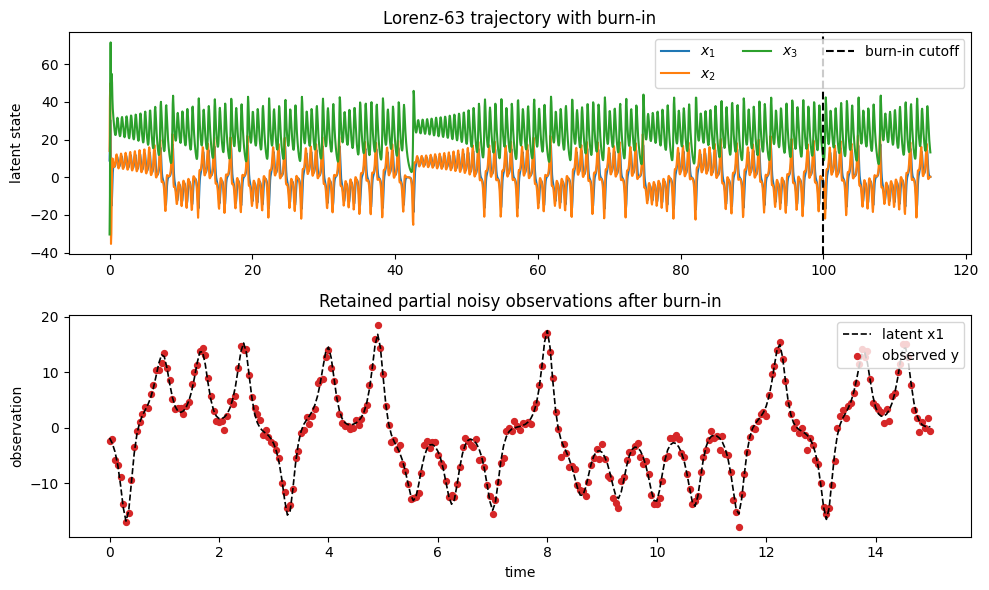

In [3]:
dataset = simulate_dataset()
obs_times = dataset["times"]
states = dataset["states"]
obs_values = dataset["observations"]
full_times = dataset["full_times"]
full_states = dataset["full_states"]
burn_in_time = float(dataset["burn_in_time"])

print("times shape:", obs_times.shape)
print("states shape:", states.shape)
print("observations shape:", obs_values.shape)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
state_labels = [r"$x_1$", r"$x_2$", r"$x_3$"]

for i, label in enumerate(state_labels):
    axes[0].plot(full_times, full_states[:, i], label=label)
axes[0].axvline(burn_in_time, color="black", linestyle="--", lw=1.5, label="burn-in cutoff")
axes[0].set_ylabel("latent state")
axes[0].set_title("Lorenz-63 trajectory with burn-in")
axes[0].legend(loc="upper right", ncol=3)

axes[1].plot(obs_times, states[:, 0], "k--", lw=1.2, label="latent x1")
axes[1].scatter(obs_times, obs_values[:, 0], s=18, color="C3", label="observed y")
axes[1].set_xlabel("time")
axes[1].set_ylabel("observation")
axes[1].set_title("Retained partial noisy observations after burn-in")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## A single scored EnKF run

The next cell records both the predictive observation summaries and the scoring-rule sites.
All scores are stored *per observation time*. In this example the observation is 1-dimensional,
so the observation-wise CRPS is also scalar per time step.


   f_predicted_observations_mean: (301, 1)
    f_predicted_observations_cov: (301, 1, 1)
f_predicted_observations_ensemble: (301, 30, 1)
             f_gaussian_log_prob: (301, 1)
              f_dawid_sebastiani: (301, 1)
         f_observation_wise_crps: (301, 1)
                  f_energy_score: (301, 1)
         f_energy_score_beta_1_5: (301, 1)

Time-averaged scores for this run (N_particles=30, CRN seed=0):
  Gaussian log-prob            (higher better): -1.4916
  Dawid-Sebastiani             (lower  better): 1.1454
  Observation-wise CRPS        (lower  better): 0.6240
  Energy score (beta=1.0)      (lower  better): 0.6279
  Energy score (beta=1.5)      (lower  better): 0.8598


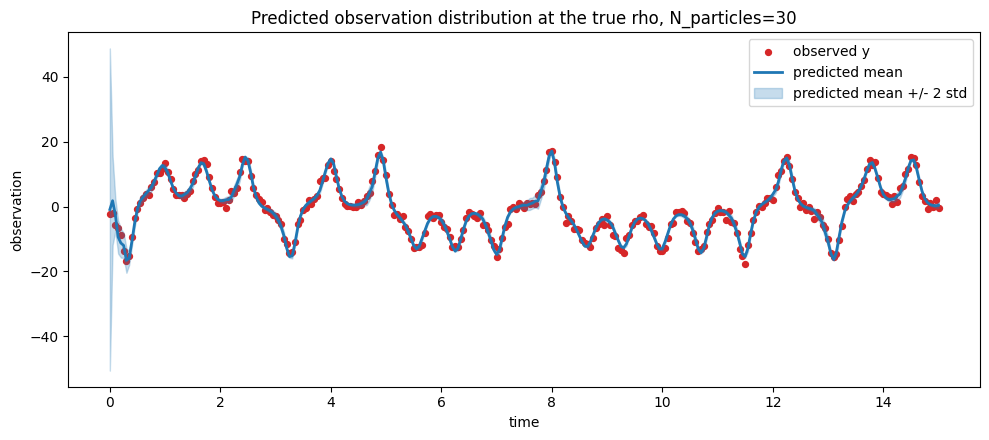


Reduced seed/rho/N_particles benchmark arrays with N_particles outermost:
  vmap shape = (2, 3, 3, 5)
  scan shape = (2, 3, 3, 5)
Maximum absolute difference between scan and vmap benchmark arrays: 3.741e-12
Steady-state reduced benchmark timings with outermost N_particles (after the equality check run):
  scan: 33.175 s
  vmap: 108.624 s


In [4]:
example_n_particles = 30
example_crn_seed = CRN_SEED_INTS[0]
example_run = run_scored_enkf(
    rho=TRUE_RHO,
    n_particles=example_n_particles,
    crn_seed_int=example_crn_seed,
    obs_times=obs_times,
    obs_values=obs_values,
)

for site_name in PREDICTION_SITE_NAMES + [name for name, _, _ in METRIC_SPECS]:
    print(f"{site_name:>32s}: {tuple(example_run[site_name].shape)}")

print(f"\nTime-averaged scores for this run (N_particles={example_n_particles}, CRN seed={example_crn_seed}):")
for site_name, label, objective in METRIC_SPECS:
    summary_value = aggregate_metric(example_run[site_name])
    print(f"  {label:28s} ({objective:6s} better): {summary_value:.4f}")

pred_mean = example_run["f_predicted_observations_mean"][:, 0]
pred_std = jnp.sqrt(example_run["f_predicted_observations_cov"][:, 0, 0])

fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
ax.scatter(obs_times, obs_values[:, 0], s=18, color="C3", label="observed y")
ax.plot(obs_times, pred_mean, color="C0", lw=2.0, label="predicted mean")
ax.fill_between(
    obs_times,
    pred_mean - 2.0 * pred_std,
    pred_mean + 2.0 * pred_std,
    color="C0",
    alpha=0.25,
    label="predicted mean +/- 2 std",
)
ax.set_xlabel("time")
ax.set_ylabel("observation")
ax.set_title(
    f"Predicted observation distribution at the true rho, N_particles={example_n_particles}"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

benchmark_particle_values = [10, 30, 100]
benchmark_rho_values = jnp.asarray([TRUE_RHO - 1.0, TRUE_RHO, TRUE_RHO + 1.0])
benchmark_seed_values = [0, 1]
benchmark_arrays, benchmark_max_abs_diff = benchmark_particle_axis_methods(
    rho_values=benchmark_rho_values,
    particle_values=benchmark_particle_values,
    obs_times=obs_times,
    obs_values=obs_values,
    seed_values=benchmark_seed_values,
)

print("\nReduced seed/rho/N_particles benchmark arrays with N_particles outermost:")
for method_name, metric_tensor in benchmark_arrays.items():
    print(f"  {method_name:4s} shape = {metric_tensor.shape}")
print(f"Maximum absolute difference between scan and vmap benchmark arrays: {benchmark_max_abs_diff:.3e}")

benchmark_timings = {}
for method_name in ("scan", "vmap"):
    start = time.perf_counter()
    _ = evaluate_metric_tensor(
        rho_values=benchmark_rho_values,
        particle_values=benchmark_particle_values,
        obs_times=obs_times,
        obs_values=obs_values,
        seed_values=benchmark_seed_values,
        particle_axis_method=method_name,
    )
    benchmark_timings[method_name] = time.perf_counter() - start

print("Steady-state reduced benchmark timings with outermost N_particles (after the equality check run):")
for method_name in ("scan", "vmap"):
    print(f"  {method_name:4s}: {benchmark_timings[method_name]:.3f} s")






## How do the scores change as we increase `N_particles`?

We now keep `rho` fixed at the truth and vary the EnKF ensemble size.
For each `N_particles`, we reuse the same 10 CRN seeds and summarize the score distribution across those runs.
The plots below show the median score with 25th/75th percentile error bars across seeds.

On a larger observation dimension you might keep the raw score arrays, average over time only,
or inspect each component separately. Here `obs_dim = 1`, so a single time average is enough.


Time-averaged EnKF scores at the true rho (median with 25th/75th percentiles across 10 shared CRN seeds):

N_particles=10
  Gaussian log-prob            (higher better): median=-1.5261, q25=-1.5585, q75=-1.5113
  Dawid-Sebastiani             (lower  better): median=1.2143, q25=1.1847, q75=1.2792
  Observation-wise CRPS        (lower  better): median=0.6468, q25=0.6389, q75=0.6643
  Energy score (beta=1.0)      (lower  better): median=0.6951, q25=0.6879, q75=0.7230
  Energy score (beta=1.5)      (lower  better): median=0.9868, q25=0.9678, q75=1.0180

N_particles=20
  Gaussian log-prob            (higher better): median=-1.4961, q25=-1.4984, q75=-1.4902
  Dawid-Sebastiani             (lower  better): median=1.1543, q25=1.1426, q75=1.1589
  Observation-wise CRPS        (lower  better): median=0.6248, q25=0.6194, q75=0.6268
  Energy score (beta=1.0)      (lower  better): median=0.6477, q25=0.6452, q75=0.6540
  Energy score (beta=1.5)      (lower  better): median=0.8918, q25=0.8904, q75=0.9

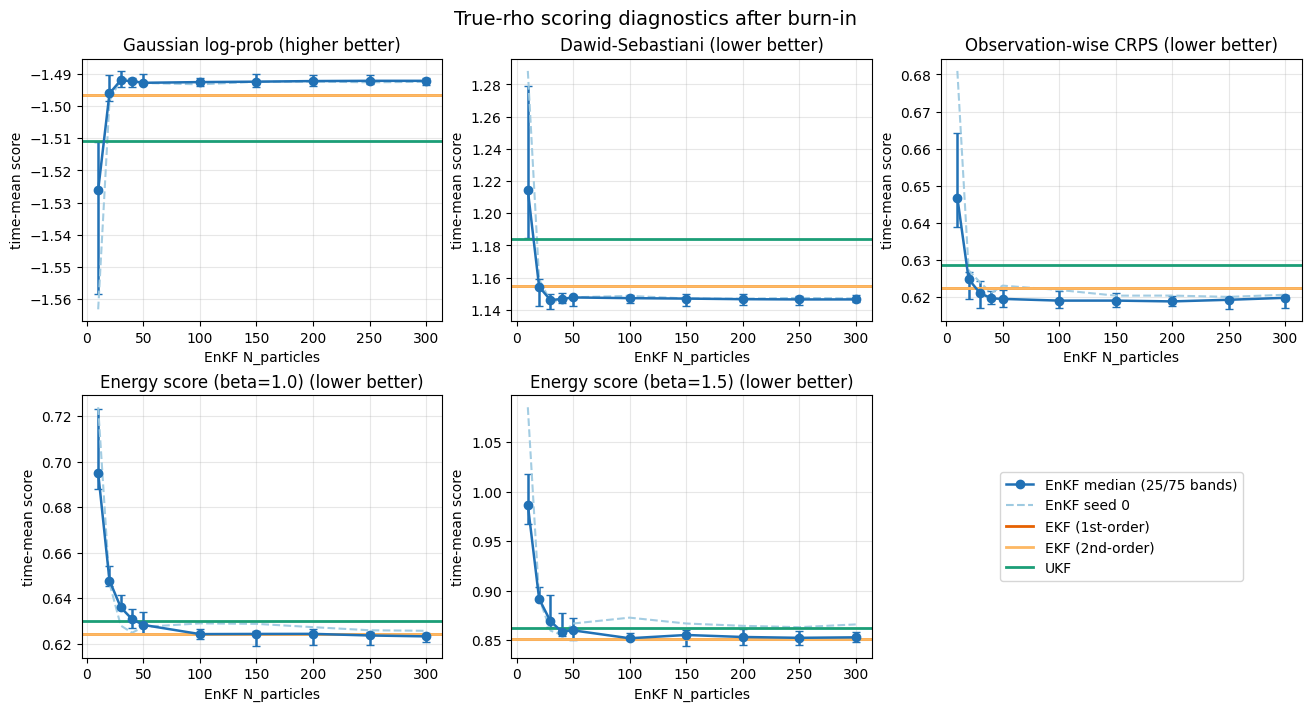

In [5]:
known_metric_tensor = evaluate_metric_tensor(
    rho_values=jnp.asarray([TRUE_RHO]),
    particle_values=N_PARTICLES_VALUES,
    obs_times=obs_times,
    obs_values=obs_values,
)[:, 0]
known_parameter_results = metric_tensor_to_summary_dict(
    known_metric_tensor,
    N_PARTICLES_VALUES,
)
baseline_true_metric_grid = evaluate_baseline_metric_grid(
    rho_values=[TRUE_RHO],
    obs_times=obs_times,
    obs_values=obs_values,
)

print("Time-averaged EnKF scores at the true rho (median with 25th/75th percentiles across 10 shared CRN seeds):\n")
for n_particles in N_PARTICLES_VALUES:
    print(f"N_particles={n_particles}")
    for site_name, label, objective in METRIC_SPECS:
        stats = known_parameter_results[n_particles][site_name]
        print(
            f"  {label:28s} ({objective:6s} better): "
            f"median={stats['median']:.4f}, q25={stats['q25']:.4f}, q75={stats['q75']:.4f}"
        )
    print()

print("Deterministic Gaussian-filter baselines at the true rho:\n")
for method_key, label, _ in BASELINE_METHOD_SPECS:
    print(label)
    for metric_idx, (_, metric_label, objective) in enumerate(METRIC_SPECS):
        value = baseline_true_metric_grid[method_key][0, metric_idx]
        print(f"  {metric_label:28s} ({objective:6s} better): value={value:.4f}")
    print()

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
axes = axes.ravel()
for ax, (site_name, label, objective) in zip(axes[:-1], METRIC_SPECS, strict=True):
    metric_idx = METRIC_SITE_NAMES.index(site_name)
    medians = [known_parameter_results[n_particles][site_name]["median"] for n_particles in N_PARTICLES_VALUES]
    q25s = [known_parameter_results[n_particles][site_name]["q25"] for n_particles in N_PARTICLES_VALUES]
    q75s = [known_parameter_results[n_particles][site_name]["q75"] for n_particles in N_PARTICLES_VALUES]
    first_seed_values = known_metric_tensor[0, :, metric_idx]
    yerr = np.vstack([
        np.asarray(medians) - np.asarray(q25s),
        np.asarray(q75s) - np.asarray(medians),
    ])
    ax.errorbar(
        N_PARTICLES_VALUES,
        medians,
        yerr=yerr,
        marker="o",
        lw=1.8,
        capsize=3,
        color=ENKF_MEDIAN_COLOR,
    )
    ax.plot(
        N_PARTICLES_VALUES,
        first_seed_values,
        linestyle="--",
        lw=1.5,
        color=ENKF_SEED_COLOR,
        alpha=0.95,
    )
    for method_key, _, color in BASELINE_METHOD_SPECS:
        ax.axhline(
            baseline_true_metric_grid[method_key][0, metric_idx],
            color=color,
            lw=2.0,
        )
    ax.set_xlabel("EnKF N_particles")
    ax.set_ylabel("time-mean score")
    ax.set_title(f"{label} ({objective} better)")
    ax.grid(alpha=0.3)

legend_handles = [
    Line2D([0], [0], color=ENKF_MEDIAN_COLOR, marker="o", lw=1.8, label="EnKF median (25/75 bands)"),
    Line2D([0], [0], color=ENKF_SEED_COLOR, linestyle="--", lw=1.5, label="EnKF seed 0"),
]
legend_handles.extend(
    Line2D([0], [0], color=color, lw=2.0, label=label)
    for method_key, label, color in BASELINE_METHOD_SPECS
)
axes[-1].axis("off")
axes[-1].legend(handles=legend_handles, loc="center")
fig.suptitle("True-rho scoring diagnostics after burn-in", fontsize=14)
plt.show()




On a single partially observed trajectory, score improvements with larger `N_particles` do not have to be monotone.
That is expected: the filter is still approximate, the dataset is finite, and the EnKF itself is stochastic.
Using the same CRN seeds for every `N_particles` value makes those comparisons fairer by isolating how the filter changes as the ensemble size changes.


## Score profiles over an unknown `rho`

Next we treat `rho` as unknown and evaluate the same scored filters over a grid.
This is the same idea as a profile likelihood, but now we can inspect multiple predictive diagnostics.

For each `N_particles` value in the EnKF profile comparison, we evaluate the same 10 CRN seeds at every `rho`.
The profile plots below again show the median score with 25th/75th percentile error bars across seeds,
plus the first seed as a dashed line to show the structure induced by the shared CRN.
The EKF baselines are deterministic here; because the observation map is linear,
their first-vs-second order difference comes from the continuous-time state propagation order.


In [6]:
profile_metric_tensor = evaluate_metric_tensor(
    rho_values=RHO_GRID,
    particle_values=PROFILE_N_PARTICLES_VALUES,
    obs_times=obs_times,
    obs_values=obs_values,
)
profile_results = profile_tensor_to_summary_dict(
    profile_metric_tensor,
    RHO_GRID,
    PROFILE_N_PARTICLES_VALUES,
)
baseline_profile_metric_grid = evaluate_baseline_metric_grid(
    rho_values=RHO_GRID,
    obs_times=obs_times,
    obs_values=obs_values,
)

for n_particles in PROFILE_N_PARTICLES_VALUES:
    print(f"Best rho values for EnKF N_particles={n_particles}:")
    for site_name, label, objective in METRIC_SPECS:
        rho_star, metric_star = best_rho(
            RHO_GRID,
            profile_results[n_particles][site_name]["median"],
            objective,
        )
        print(f"  {label:28s} -> rho={rho_star:5.2f}, median score={metric_star:.4f}")
    print()

for method_key, baseline_label, _ in BASELINE_METHOD_SPECS:
    print(f"Best rho values for {baseline_label}:")
    for metric_idx, (site_name, label, objective) in enumerate(METRIC_SPECS):
        rho_star, metric_star = best_rho(
            RHO_GRID,
            baseline_profile_metric_grid[method_key][:, metric_idx],
            objective,
        )
        print(f"  {label:28s} -> rho={rho_star:5.2f}, value={metric_star:.4f}")
    print()




Best rho values for EnKF N_particles=10:
  Gaussian log-prob            -> rho=28.00, median score=-1.5261
  Dawid-Sebastiani             -> rho=28.00, median score=1.2143
  Observation-wise CRPS        -> rho=28.00, median score=0.6468
  Energy score (beta=1.0)      -> rho=28.00, median score=0.6951
  Energy score (beta=1.5)      -> rho=28.00, median score=0.9868

Best rho values for EnKF N_particles=30:
  Gaussian log-prob            -> rho=28.00, median score=-1.4920
  Dawid-Sebastiani             -> rho=28.00, median score=1.1461
  Observation-wise CRPS        -> rho=28.00, median score=0.6211
  Energy score (beta=1.0)      -> rho=28.00, median score=0.6359
  Energy score (beta=1.5)      -> rho=28.00, median score=0.8692

Best rho values for EnKF N_particles=100:
  Gaussian log-prob            -> rho=28.00, median score=-1.4926
  Dawid-Sebastiani             -> rho=28.00, median score=1.1473
  Observation-wise CRPS        -> rho=28.00, median score=0.6190
  Energy score (beta=1.0) 

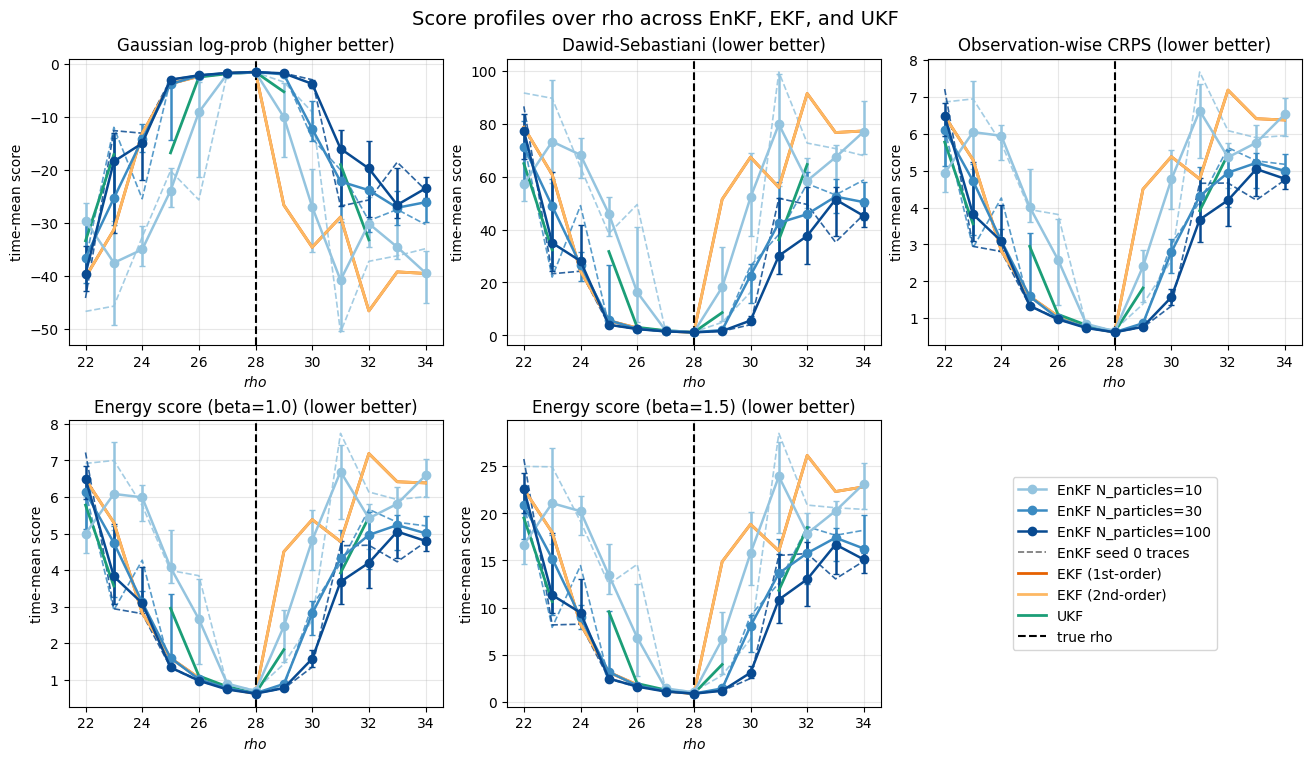

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), constrained_layout=True)
axes = axes.ravel()
profile_colors = make_enkf_color_map(PROFILE_N_PARTICLES_VALUES)

for ax, (site_name, label, objective) in zip(axes[:-1], METRIC_SPECS, strict=True):
    metric_idx = METRIC_SITE_NAMES.index(site_name)
    for particle_idx, n_particles in enumerate(PROFILE_N_PARTICLES_VALUES):
        medians = profile_results[n_particles][site_name]["median"]
        q25s = profile_results[n_particles][site_name]["q25"]
        q75s = profile_results[n_particles][site_name]["q75"]
        seed0_values = profile_metric_tensor[0, :, particle_idx, metric_idx]
        yerr = np.vstack([
            np.asarray(medians) - np.asarray(q25s),
            np.asarray(q75s) - np.asarray(medians),
        ])
        ax.errorbar(
            np.asarray(RHO_GRID),
            medians,
            yerr=yerr,
            marker="o",
            lw=1.8,
            capsize=2,
            color=profile_colors[n_particles],
        )
        ax.plot(
            np.asarray(RHO_GRID),
            seed0_values,
            linestyle="--",
            lw=1.2,
            color=profile_colors[n_particles],
            alpha=0.85,
        )
    for method_key, _, color in BASELINE_METHOD_SPECS:
        ax.plot(
            np.asarray(RHO_GRID),
            baseline_profile_metric_grid[method_key][:, metric_idx],
            color=color,
            lw=2.0,
        )
    ax.axvline(TRUE_RHO, color="black", linestyle="--", lw=1.5)
    ax.set_xlabel(r"$rho$")
    ax.set_ylabel("time-mean score")
    ax.set_title(f"{label} ({objective} better)")
    ax.grid(alpha=0.3)

legend_handles = [
    Line2D([0], [0], color=profile_colors[n_particles], marker="o", lw=1.8, label=f"EnKF N_particles={n_particles}")
    for n_particles in PROFILE_N_PARTICLES_VALUES
]
legend_handles.append(
    Line2D([0], [0], color="0.45", linestyle="--", lw=1.2, label="EnKF seed 0 traces")
)
legend_handles.extend(
    Line2D([0], [0], color=color, lw=2.0, label=label)
    for method_key, label, color in BASELINE_METHOD_SPECS
)
legend_handles.append(
    Line2D([0], [0], color="black", linestyle="--", lw=1.5, label="true rho")
)
axes[-1].axis("off")
axes[-1].legend(handles=legend_handles, loc="center")
fig.suptitle("Score profiles over rho across EnKF, EKF, and UKF", fontsize=14)
plt.show()



## Takeaways

- `ObservationScoringConfig` gives you time-resolved predictive diagnostics directly from `Filter(...)`.
- Those diagnostics can be recorded as NumPyro sites alongside the predicted observation summaries.
- For EnKF, changing `N_particles` changes both the predictive approximation and the Monte Carlo noise in the scores.
- Reusing the same CRN seeds across `N_particles` values makes these comparisons much fairer.
- Using medians with 25th/75th percentile bands gives a more robust picture of seed-to-seed variability than mean +/- std.
- Score profiles over parameters can reveal behavior that would be invisible if you only inspected the marginal likelihood.

To adapt this pattern to your own model, keep the same scoring config, turn on whichever
`record_predicted_observations_*` sites you want, and aggregate the resulting score arrays
however makes sense for your workflow.
